# 🛡️ Insurance Claims & Portfolio Analysis

An exploratory analysis of **10,000 insurance policies** covering five lines of
business (Travel, Health, Auto, Life, Home). The notebook walks through the
book question by question: how the portfolio is composed, what happens to the
claims that are filed, which lines are profitable, and how customers differ by
gender and age.

Every number and chart below is produced by the reusable, tested functions in
[`src/`](../src) — the notebook is a narrative on top of the package, not a
pile of one-off cells.

## 0. Setup

In [1]:
%matplotlib inline
import pathlib
import sys

ROOT = pathlib.Path.cwd()
if not (ROOT / "src").is_dir() and (ROOT.parent / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display

from src import analysis, visualization
from src.data_cleaning import clean_data, validate_data
from src.data_loader import load_data
from src.feature_engineering import compute_derived_columns

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 40)
print("Project root:", ROOT)

Project root: D:\portfolio\Insurance Data Analysis


## 1. Load, clean and enrich the data

The raw file repeats a handful of policies, stores dates as `DD-MM-YYYY`
strings and leaves claim fields empty for rejected claims. The pipeline drops
exact duplicates, parses the dates, validates the business rules and derives
the columns used later (age bands, claim lag, loss ratios).

In [2]:
raw = load_data(ROOT / "data" / "insurance_data.csv")
df = compute_derived_columns(validate_data(clean_data(raw)))
print(f"Raw rows: {len(raw):,}  ->  clean, valid rows: {len(df):,}")
df.head()

Raw rows: 10,004  ->  clean, valid rows: 10,000


,PolicyNumber,CustomerID,Gender,Age,PolicyType,PolicyStartDate,PolicyEndDate,PremiumAmount,CoverageAmount,ClaimNumber,ClaimDate,ClaimAmount,ClaimStatus,PolicyYear,PolicyMonth,PolicyQuarter,PolicyDurationDays,AgeBand,IsSettled,IsPending,IsRejected,HasValidClaim,CoverageToPremiumRatio,ClaimToPremiumRatio,ClaimToCoverageRatio,ClaimLagDays
0,P1,C1,Female,73,Auto,2024-02-13,2025-02-13,240.64,"33,175.10",C1,NaT,0.00,Rejected,2024,2024-02,2024Q1,366,65+,False,False,True,False,137.86,0.00,0.00,NaN
1,P2,C2,Male,44,Travel,2024-03-03,2025-03-03,"1,059.73","85,046.42",C2,2024-06-22,"1,493.06",Pending,2024,2024-03,2024Q1,365,36-45,False,True,False,True,80.25,1.41,0.02,111.00
2,P3,C3,Female,28,Travel,2024-06-15,2025-06-15,"1,019.59","68,525.53",C3,NaT,0.00,Rejected,2024,2024-06,2024Q2,365,26-35,False,False,True,False,67.21,0.00,0.00,NaN
3,P4,C4,Male,85,Travel,2024-06-03,2025-06-03,549.70,"17,053.27",C4,2025-02-25,"5,021.34",Pending,2024,2024-06,2024Q2,365,65+,False,True,False,True,31.02,9.13,0.29,267.00
4,P5,C5,Female,57,Travel,2024-06-13,2025-06-13,841.15,"55,007.27",C5,2024-11-30,"1,347.46",Pending,2024,2024-06,2024Q2,365,56-65,False,True,False,True,65.40,1.60,0.02,170.00


## 2. Q1 — Portfolio overview

In [3]:
summary = analysis.portfolio_summary(df)
summary

Policies                   10000
Customers                  10000
Total Premium       5,974,060.08
Total Coverage    600,331,176.46
Settled Claims              3386
Pending Claims              2260
Rejected Claims             4354
Settled Payout     10,105,060.19
Pending Payout      6,799,235.08
Loss Ratio %              169.10
dtype: object

## 3. Q2 — How is the book split across policy types?

Travel is by far the largest line by policy count, but premium is spread far
more evenly — average premium is almost identical across products.

,Policies,TotalPremium,AvgPremium,TotalCoverage,AvgCoverage,AvgCoverageToPremium
PolicyType,,,,,,
Travel,4145,"2,475,660.83",597.26,"250,638,513.79","60,467.68",101.20
Health,2000,"1,199,727.04",599.86,"120,101,820.35","60,050.91",100.10
Auto,1594,"959,623.10",602.02,"94,433,710.42","59,243.23",98.40
Life,1248,"734,816.05",588.79,"74,103,544.12","59,377.84",100.80
Home,1013,"604,233.06",596.48,"61,053,587.78","60,270.08",101.00


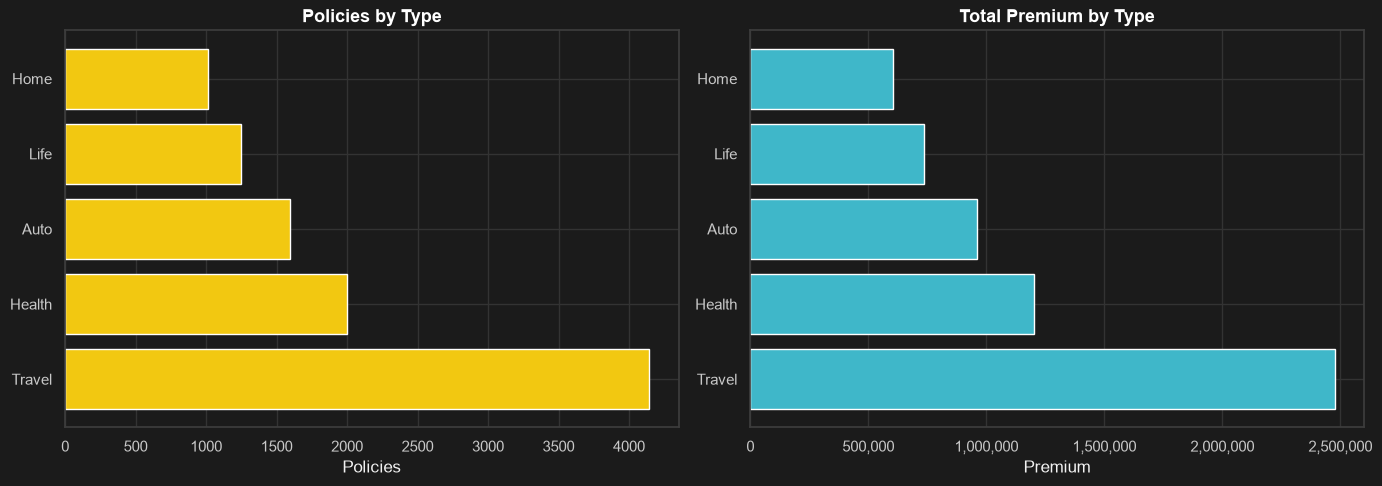

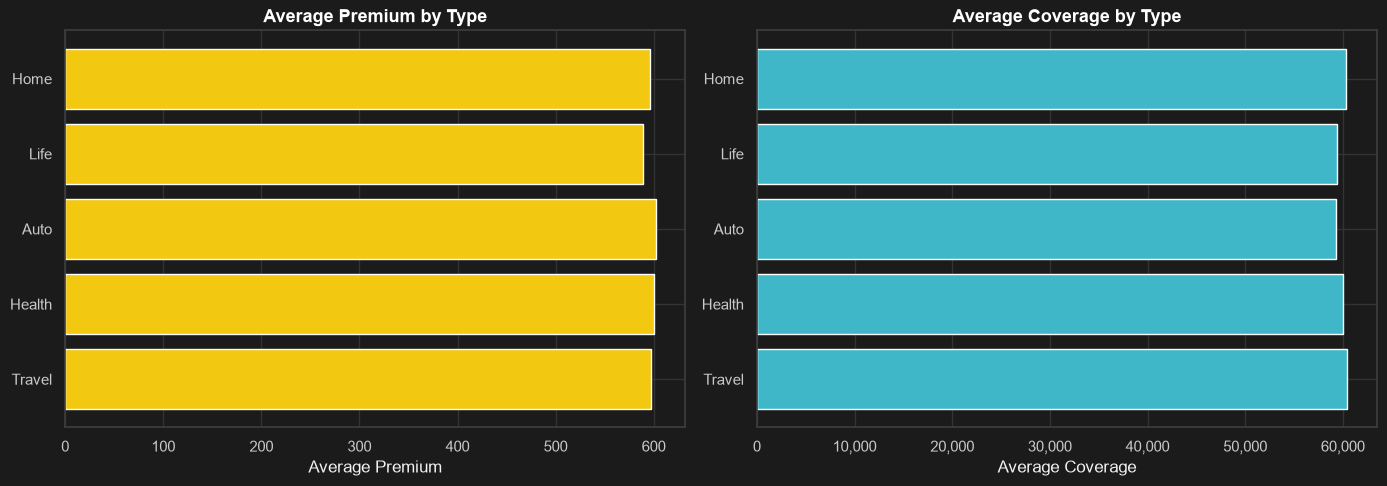

In [4]:
by_type = analysis.premium_and_coverage_by_policy_type(df)
display(by_type)
visualization.plot_policies_and_premium(by_type);
visualization.plot_premium_and_coverage(by_type);

## 4. Q3 — What happens to the claims?

Claim outcomes are remarkably consistent across lines: roughly **one third
settled, one fifth pending and the rest rejected**. The rejection rate is the
single biggest driver of the loss ratio below.

,Settled,Pending,Rejected,Settled %,Pending %,Rejected %
PolicyType,,,,,,
Travel,1428,937,1780,34.50,22.60,42.90
Health,675,458,867,33.80,22.90,43.40
Auto,564,357,673,35.40,22.40,42.20
Life,386,296,566,30.90,23.70,45.40
Home,333,212,468,32.90,20.90,46.20


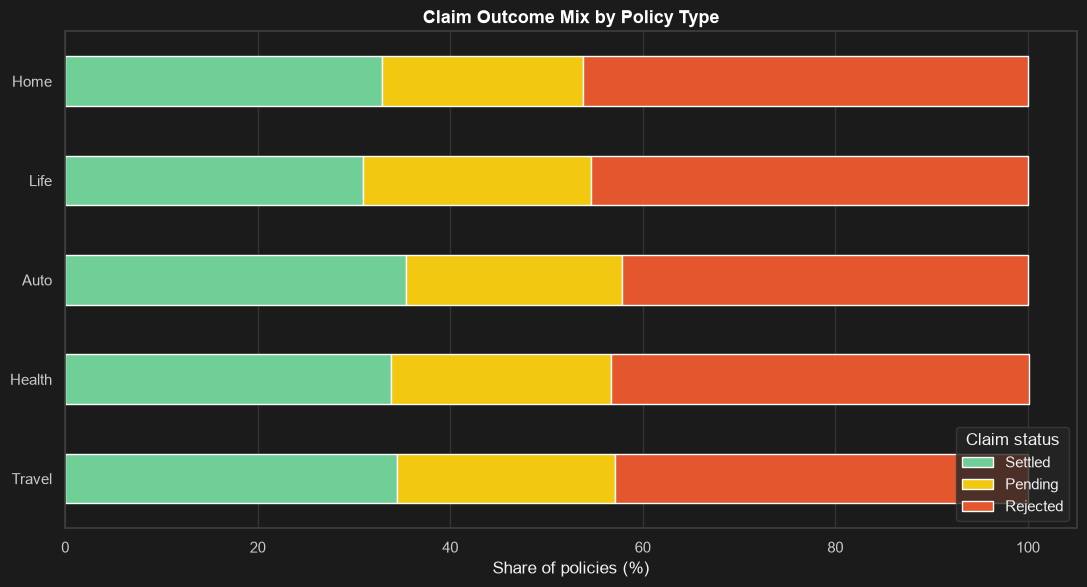

In [5]:
outcomes = analysis.claim_outcomes_by_policy_type(df)
display(outcomes)
visualization.plot_claim_outcomes(outcomes);

## 5. Q4 — Which lines are profitable?

The **loss ratio** compares settled payouts to premium collected. Anything
above 100% means the line pays out more than it takes in. Every single line is
above 100%.

,Premium,Settled Payout,Loss Ratio %
PolicyType,,,
Auto,"959,623.10","1,666,024.45",173.61
Travel,"2,475,660.83","4,282,858.09",173.00
Health,"1,199,727.04","1,997,685.01",166.51
Life,"734,816.05","1,187,574.15",161.62
Home,"604,233.06","970,918.49",160.69


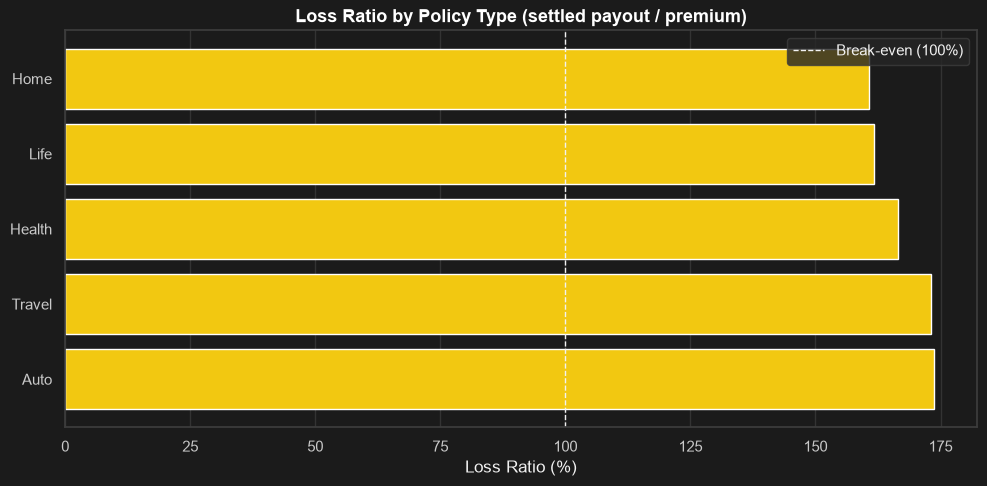

In [6]:
loss_ratio = analysis.loss_ratio_by_policy_type(df)
display(loss_ratio)
visualization.plot_loss_ratio(loss_ratio);

## 6. Q5 — Claim status mix

,Claims
ClaimStatus,
Rejected,4354
Settled,3386
Pending,2260


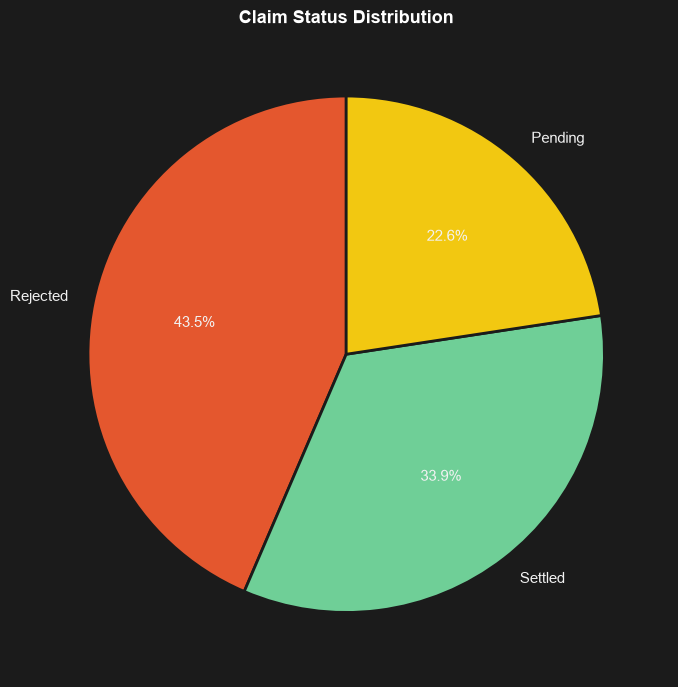

In [7]:
status = analysis.claim_status_distribution(df)
display(status.to_frame("Claims"))
visualization.plot_claim_status_distribution(status);

## 7. Q6 — Do men and women behave differently?

Premium and claim frequency are nearly identical between genders. Men carry a
marginally higher loss ratio, but the gap is small.

,Policies,TotalPremium,AvgPremium,ValidClaimRate,SettledPayout,Loss Ratio %
Gender,,,,,,
Female,5000,"2,990,563.86",598.11,56.10,"4,995,850.95",167.10
Male,5000,"2,983,496.22",596.70,56.80,"5,109,209.24",171.20


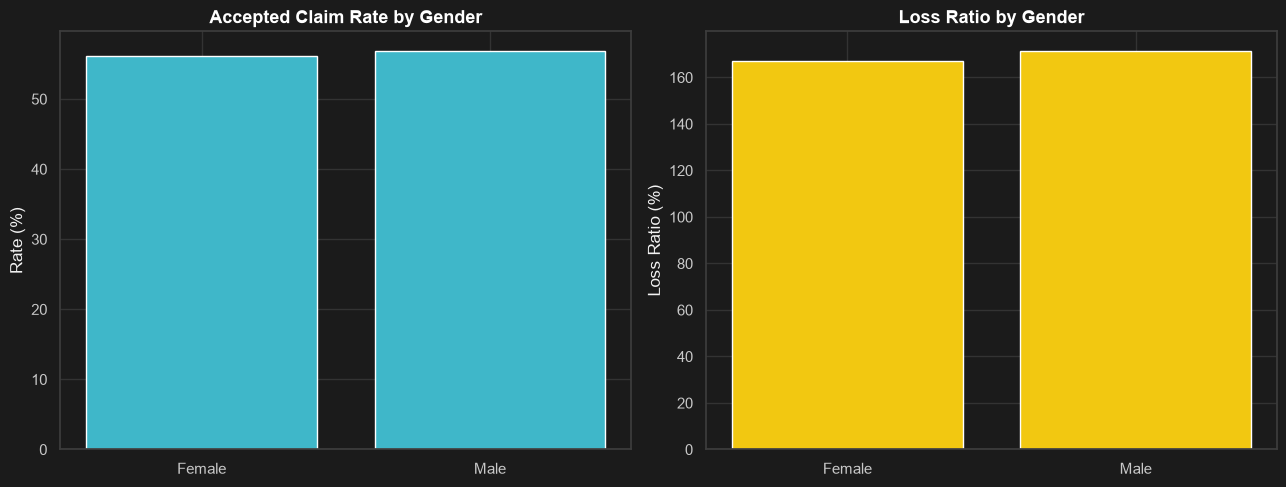

In [8]:
by_gender = analysis.claims_by_gender(df)
display(by_gender)
visualization.plot_claims_by_gender(by_gender);

## 8. Q7 — How does age relate to claims?

Average premium is essentially flat across age bands, while the accepted claim
rate rises through middle age and peaks for 36–45 year olds.

,Policies,AvgPremium,ValidClaimRate,SettledPayout,Loss Ratio %
AgeBand,,,,,
18-25,1161,582.16,56.30,"1,085,020.24",160.50
26-35,1437,594.35,54.50,"1,340,699.36",157.00
36-45,1461,599.73,57.80,"1,528,287.77",174.40
46-55,1429,601.93,57.50,"1,505,434.10",175.00
56-65,1409,596.35,56.10,"1,507,943.87",179.50
65+,3103,601.83,56.50,"3,137,674.85",168.00


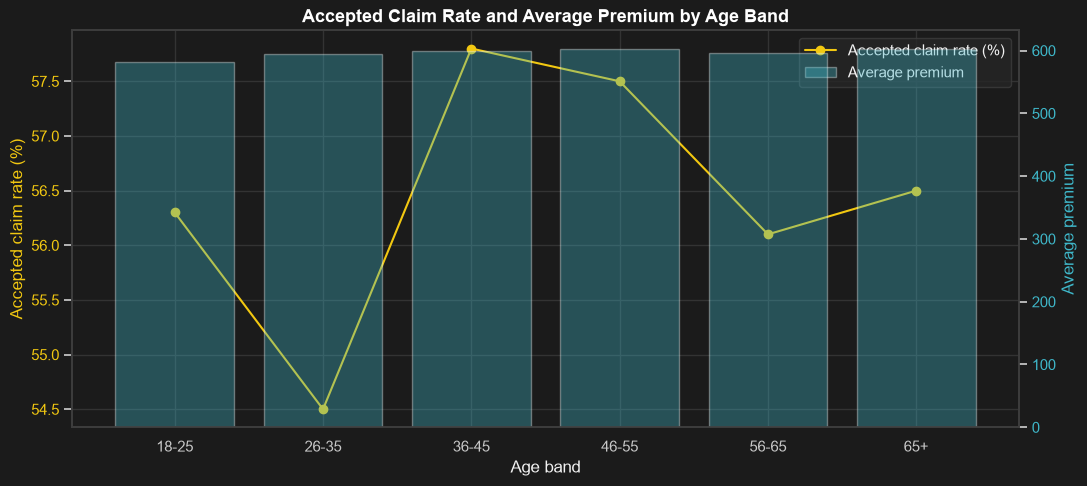

In [9]:
by_age = analysis.age_band_analysis(df)
display(by_age)
visualization.plot_age_bands(by_age);

## 9. Q8 — How does the book move over time?

Policies are written steadily through the year, and the settled payout curve
lags originations by a few months — exactly what you would expect if claims
take time to be reported and processed (median lag is about six months).

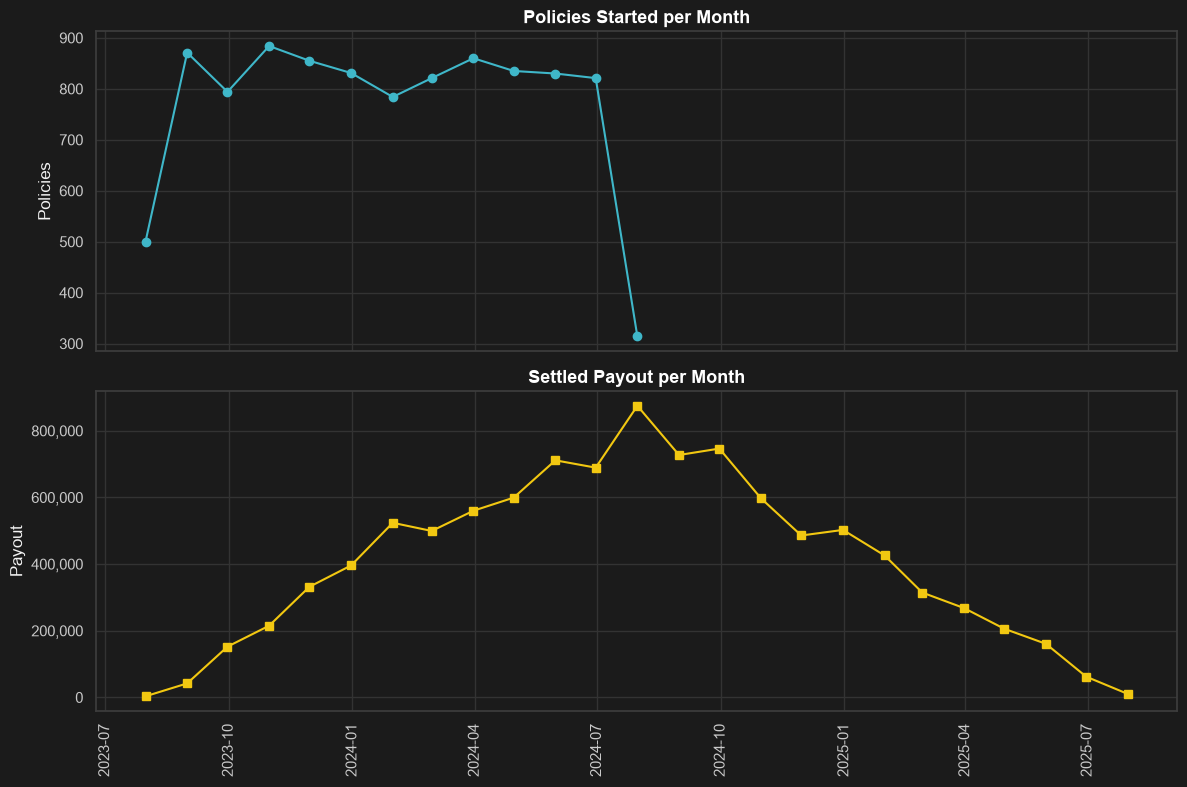

In [10]:
policies = analysis.policies_over_time(df)
claims = analysis.claims_over_time(df)
visualization.plot_policies_over_time(policies, claims);

## 10. Q9 — How large are paid claims?

,Claims,Mean,Median,P90,Max
PolicyType,,,,,
Life,386,"3,076.62","3,019.80","5,071.17","5,491.77"
Travel,1428,"2,999.20","2,986.82","5,017.05","5,489.38"
Health,675,"2,959.53","2,934.91","4,979.01","5,477.51"
Auto,564,"2,953.94","2,803.40","5,013.94","5,498.58"
Home,333,"2,915.67","2,841.37","4,930.91","5,494.70"


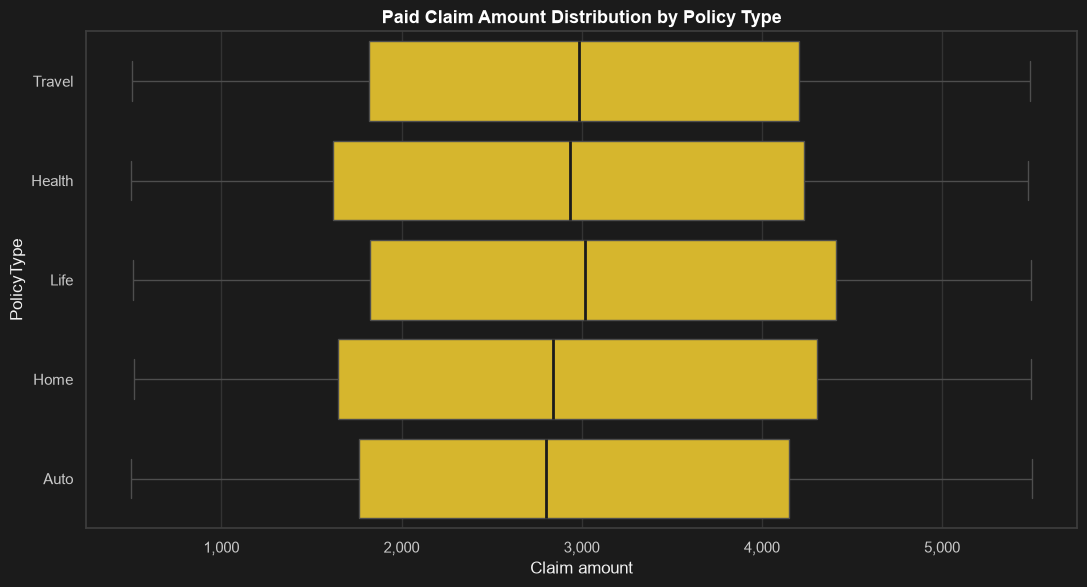

In [11]:
severity = analysis.claim_severity_by_policy_type(df)
display(severity)
visualization.plot_claim_severity(df);

## 11. Q10 — Is coverage priced in line with premium?

Coverage and premium are effectively **uncorrelated** (r ≈ 0): a customer
paying a higher premium is not buying proportionally more cover. This is worth
flagging to the pricing team.

Pearson r (premium vs. coverage): 0.003


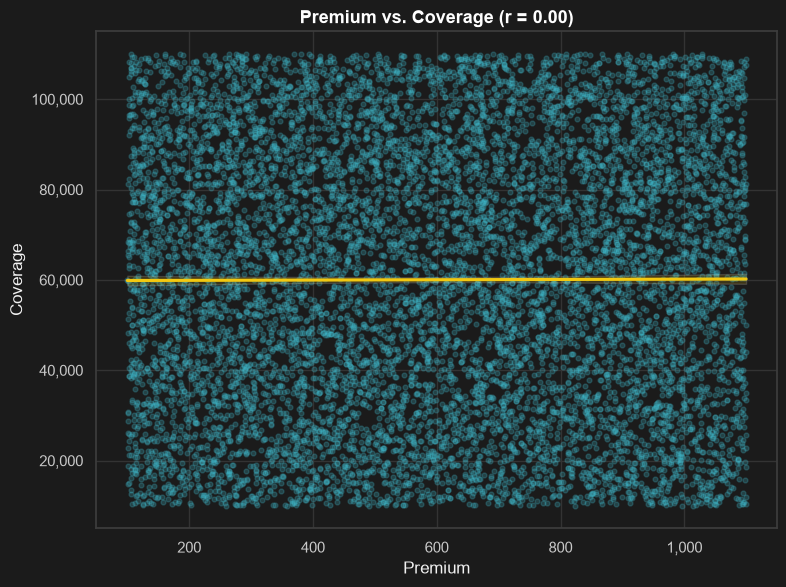

In [12]:
corr = analysis.premium_coverage_correlation(df)
print(f"Pearson r (premium vs. coverage): {corr:.3f}")
visualization.plot_premium_coverage_relationship(df, corr);

## 12. Key findings

1. **The book is loss-making.** The overall loss ratio is ~169% — every line
   pays out more in settled claims than it collects in premium.
2. **Rejections mask the true cost.** About 43% of claims are rejected; if the
   2,260 pending claims settle at the same rate as the settled ones, the
   eventual payout rises further.
3. **Product mix is skewed.** Travel accounts for ~41% of policies, yet
   average premium is flat across products — pricing is not risk-based.
4. **Demographics are neutral.** Gender and age barely move premium or claim
   frequency, so they are not strong rating factors in this dataset.
5. **Coverage is not priced proportionally.** Premium and coverage are
   uncorrelated (r ≈ 0), a clear pricing red flag.

> **Note on the data.** This is a synthetic sample used for demonstration. The
> amounts are unit-less and the customer identifiers are not real people.